In [1]:
# ============================================================
# Cell 1 : Environment Setup
# Purpose : Import Libraries & Check System Information
# ============================================================

import os
import cv2
import time
import json
import shutil
import joblib
import platform
import warnings
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

# Image Processing
from skimage.feature import local_binary_pattern

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

warnings.filterwarnings("ignore")

print("="*60)
print("Real-Time Violence Detection")
print("Traditional Machine Learning Baseline")
print("Model : LBP + Linear SVM")
print("="*60)

print(f"Python Version : {platform.python_version()}")
print(f"OpenCV Version : {cv2.__version__}")

try:
    import sklearn
    print(f"Scikit-Learn Version : {sklearn.__version__}")
except:
    pass

print(f"Numpy Version : {np.__version__}")

print("="*60)
print("Environment Ready")
print("="*60)

Real-Time Violence Detection
Traditional Machine Learning Baseline
Model : LBP + Linear SVM
Python Version : 3.12.13
OpenCV Version : 4.13.0
Scikit-Learn Version : 1.6.1
Numpy Version : 2.0.2
Environment Ready


In [2]:
# ============================================================
# Cell 2 : Mount Google Drive & Create Project Directories
# ============================================================

from google.colab import drive
import os

print("="*60)
print("Mounting Google Drive...")
print("="*60)

drive.mount('/content/drive')

# ------------------------------------------------------------
# Main Project Folder
# ------------------------------------------------------------

PROJECT_DIR = "/content/drive/MyDrive/LBP_SVM_Violence_Detection"

MODEL_DIR = os.path.join(PROJECT_DIR, "model")
CACHE_DIR = os.path.join(PROJECT_DIR, "cache")
GRAPH_DIR = os.path.join(PROJECT_DIR, "graphs")
REPORT_DIR = os.path.join(PROJECT_DIR, "reports")

# Create directories

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(GRAPH_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

print("\nProject Directory Structure")

print("-"*60)

print(PROJECT_DIR)
print("│")
print("├── model/")
print("├── cache/")
print("├── graphs/")
print("└── reports/")

print("-"*60)

print("\nDirectories Created Successfully")

print(f"\nProject Location:\n{PROJECT_DIR}")

print("="*60)

Mounting Google Drive...
Mounted at /content/drive

Project Directory Structure
------------------------------------------------------------
/content/drive/MyDrive/LBP_SVM_Violence_Detection
│
├── model/
├── cache/
├── graphs/
└── reports/
------------------------------------------------------------

Directories Created Successfully

Project Location:
/content/drive/MyDrive/LBP_SVM_Violence_Detection


In [3]:
# ============================================================
# Cell 3 : Locate Existing Extracted Frames
# Purpose : Reuse Frames from CNN Project
# ============================================================

import os

print("=" * 60)
print("Locating Existing Extracted Frames...")
print("=" * 60)

# ------------------------------------------------------------
# Existing Frame Directory (Created during CNN Training)
# ------------------------------------------------------------

FRAMES_DIR = "/content/drive/MyDrive/Violence_Detection_Frames"

VIOLENCE_DIR = os.path.join(FRAMES_DIR, "Violence")
NONVIOLENCE_DIR = os.path.join(FRAMES_DIR, "NonViolence")

# ------------------------------------------------------------
# Verify Dataset
# ------------------------------------------------------------

if not os.path.exists(FRAMES_DIR):
    raise FileNotFoundError(
        f"\nFrame directory not found:\n{FRAMES_DIR}\n"
        "Please make sure your extracted frames are available in Google Drive."
    )

if not os.path.exists(VIOLENCE_DIR):
    raise FileNotFoundError("Violence folder not found!")

if not os.path.exists(NONVIOLENCE_DIR):
    raise FileNotFoundError("NonViolence folder not found!")

violence_count = len(os.listdir(VIOLENCE_DIR))
nonviolence_count = len(os.listdir(NONVIOLENCE_DIR))

total_images = violence_count + nonviolence_count

print("Dataset Found Successfully")
print("-" * 60)

print(f"Violence Images      : {violence_count:,}")
print(f"Non-Violence Images  : {nonviolence_count:,}")
print(f"Total Images         : {total_images:,}")

print("-" * 60)

print("\nDataset Location")
print(FRAMES_DIR)

print("=" * 60)

Locating Existing Extracted Frames...
Dataset Found Successfully
------------------------------------------------------------
Violence Images      : 11,988
Non-Violence Images  : 11,964
Total Images         : 23,952
------------------------------------------------------------

Dataset Location
/content/drive/MyDrive/Violence_Detection_Frames


In [4]:
# ============================================================
# Cell 4 : Create Dataset & Train-Test Split
# Purpose : Same Data Split as CNN Model
# ============================================================

import os
import random
import pandas as pd
from sklearn.model_selection import train_test_split

print("=" * 60)
print("Preparing Dataset...")
print("=" * 60)

# ------------------------------------------------------------
# Read Image Paths
# ------------------------------------------------------------

image_paths = []
labels = []

# Violence Images
for img in sorted(os.listdir(VIOLENCE_DIR)):
    image_paths.append(os.path.join(VIOLENCE_DIR, img))
    labels.append(1)

# Non-Violence Images
for img in sorted(os.listdir(NONVIOLENCE_DIR)):
    image_paths.append(os.path.join(NONVIOLENCE_DIR, img))
    labels.append(0)

# ------------------------------------------------------------
# Create DataFrame
# ------------------------------------------------------------

dataset = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

# Shuffle Dataset (for reproducibility)
dataset = dataset.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nDataset Created Successfully")
print("-" * 60)

print(dataset.head())

print("-" * 60)

print("Class Distribution")

print(dataset["label"].value_counts())

# ------------------------------------------------------------
# Train-Test Split (Same as CNN)
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    dataset["image_path"],
    dataset["label"],
    test_size=0.20,
    random_state=42,
    stratify=dataset["label"]
)

# Convert to numpy arrays

X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

print("\nTrain-Test Split Completed")

print("-" * 60)

print(f"Training Images : {len(X_train):,}")
print(f"Testing Images  : {len(X_test):,}")

print(f"\nTraining Violence     : {sum(y_train==1):,}")
print(f"Training NonViolence  : {sum(y_train==0):,}")

print(f"\nTesting Violence      : {sum(y_test==1):,}")
print(f"Testing NonViolence   : {sum(y_test==0):,}")

print("=" * 60)

Preparing Dataset...

Dataset Created Successfully
------------------------------------------------------------
                                          image_path  label
0  /content/drive/MyDrive/Violence_Detection_Fram...      1
1  /content/drive/MyDrive/Violence_Detection_Fram...      1
2  /content/drive/MyDrive/Violence_Detection_Fram...      0
3  /content/drive/MyDrive/Violence_Detection_Fram...      0
4  /content/drive/MyDrive/Violence_Detection_Fram...      1
------------------------------------------------------------
Class Distribution
label
1    11988
0    11964
Name: count, dtype: int64

Train-Test Split Completed
------------------------------------------------------------
Training Images : 19,161
Testing Images  : 4,791

Training Violence     : 9,590
Training NonViolence  : 9,571

Testing Violence      : 2,398
Testing NonViolence   : 2,393


In [5]:
# ============================================================
# Cell 5 : LBP Feature Extraction (Optimized)
# Purpose : Extract Uniform LBP Histogram Features
# ============================================================

import cv2
import time
import joblib
import numpy as np
from tqdm import tqdm
from joblib import Parallel, delayed
from skimage.feature import local_binary_pattern

print("=" * 60)
print("LBP Feature Extraction")
print("=" * 60)

# ------------------------------------------------------------
# LBP Parameters (Research Standard)
# ------------------------------------------------------------

RADIUS = 1
N_POINTS = 8 * RADIUS
METHOD = "uniform"

print(f"Radius           : {RADIUS}")
print(f"Neighbors        : {N_POINTS}")
print(f"Method           : {METHOD}")

# ------------------------------------------------------------
# Cache Files
# ------------------------------------------------------------

TRAIN_FEATURES = os.path.join(CACHE_DIR, "train_features.npy")
TEST_FEATURES = os.path.join(CACHE_DIR, "test_features.npy")

TRAIN_LABELS = os.path.join(CACHE_DIR, "train_labels.npy")
TEST_LABELS = os.path.join(CACHE_DIR, "test_labels.npy")

# ------------------------------------------------------------
# Feature Extraction Function
# ------------------------------------------------------------

def extract_lbp_features(image_path):

    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        return np.zeros(N_POINTS + 2)

    # Resize for faster processing
    image = cv2.resize(image, (128,128))

    lbp = local_binary_pattern(
        image,
        P=N_POINTS,
        R=RADIUS,
        method=METHOD
    )

    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, N_POINTS + 3),
        range=(0, N_POINTS + 2)
    )

    hist = hist.astype("float32")

    hist /= (hist.sum() + 1e-7)

    return hist

# ------------------------------------------------------------
# Check Cache
# ------------------------------------------------------------

if (os.path.exists(TRAIN_FEATURES) and
    os.path.exists(TEST_FEATURES) and
    os.path.exists(TRAIN_LABELS) and
    os.path.exists(TEST_LABELS)):

    print("\nCached Features Found")
    print("Loading...")

    X_train_features = np.load(TRAIN_FEATURES)
    X_test_features = np.load(TEST_FEATURES)

    y_train_features = np.load(TRAIN_LABELS)
    y_test_features = np.load(TEST_LABELS)

else:

    print("\nNo Cache Found")
    print("Extracting LBP Features...")

    start = time.time()

    # --------------------------------------------------------
    # Training Features
    # --------------------------------------------------------

    X_train_features = Parallel(
        n_jobs=-1,
        backend="threading"
    )(
        delayed(extract_lbp_features)(img)
        for img in tqdm(
            X_train,
            desc="Training Images"
        )
    )

    # --------------------------------------------------------
    # Testing Features
    # --------------------------------------------------------

    X_test_features = Parallel(
        n_jobs=-1,
        backend="threading"
    )(
        delayed(extract_lbp_features)(img)
        for img in tqdm(
            X_test,
            desc="Testing Images"
        )
    )

    X_train_features = np.array(X_train_features,dtype=np.float32)
    X_test_features = np.array(X_test_features,dtype=np.float32)

    y_train_features = np.array(y_train)
    y_test_features = np.array(y_test)

    # --------------------------------------------------------
    # Save Cache
    # --------------------------------------------------------

    np.save(TRAIN_FEATURES,X_train_features)
    np.save(TEST_FEATURES,X_test_features)

    np.save(TRAIN_LABELS,y_train_features)
    np.save(TEST_LABELS,y_test_features)

    end = time.time()

    print("\nLBP Extraction Completed")

    print(f"Time Taken : {(end-start)/60:.2f} Minutes")

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\nFeature Extraction Summary")

print("-"*60)

print(f"Training Feature Shape : {X_train_features.shape}")
print(f"Testing Feature Shape  : {X_test_features.shape}")

print(f"Feature Dimension      : {X_train_features.shape[1]}")

print("-"*60)

print("Feature Cache Location")

print(CACHE_DIR)

print("="*60)

LBP Feature Extraction
Radius           : 1
Neighbors        : 8
Method           : uniform

No Cache Found
Extracting LBP Features...


Testing Images: 100%|██████████| 4791/4791 [10:29<00:00,  7.61it/s]



LBP Extraction Completed
Time Taken : 53.53 Minutes

Feature Extraction Summary
------------------------------------------------------------
Training Feature Shape : (19161, 10)
Testing Feature Shape  : (4791, 10)
Feature Dimension      : 10
------------------------------------------------------------
Feature Cache Location
/content/drive/MyDrive/LBP_SVM_Violence_Detection/cache


In [6]:
# ============================================================
# Cell 6 : Train Optimized Linear SVM using GridSearchCV
# ============================================================

import time
import joblib

from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

print("="*60)
print("Training Linear SVM (Hyperparameter Tuning)")
print("="*60)

# ------------------------------------------------------------
# Parameter Grid
# ------------------------------------------------------------

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

# ------------------------------------------------------------
# Base Model
# ------------------------------------------------------------

svm = LinearSVC(
    random_state=42,
    max_iter=10000
)

# ------------------------------------------------------------
# Grid Search
# ------------------------------------------------------------

grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

print("\nStarting Training...\n")

start_time = time.time()

grid_search.fit(X_train_features, y_train_features)

training_time = time.time() - start_time

# ------------------------------------------------------------
# Best Model
# ------------------------------------------------------------

best_model = grid_search.best_estimator_

print("\nTraining Completed Successfully")
print("-"*60)

print(f"Best C Value           : {grid_search.best_params_['C']}")
print(f"Best CV Accuracy       : {grid_search.best_score_:.4f}")
print(f"Training Time          : {training_time:.2f} seconds")

print("="*60)

# ------------------------------------------------------------
# Save Model
# ------------------------------------------------------------

MODEL_PATH = os.path.join(MODEL_DIR, "lbp_svm_model.pkl")

joblib.dump(best_model, MODEL_PATH)

print("\nModel Saved Successfully")

print(MODEL_PATH)

print("="*60)

Training Linear SVM (Hyperparameter Tuning)

Starting Training...

Fitting 5 folds for each of 5 candidates, totalling 25 fits

Training Completed Successfully
------------------------------------------------------------
Best C Value           : 100
Best CV Accuracy       : 0.7420
Training Time          : 4.40 seconds

Model Saved Successfully
/content/drive/MyDrive/LBP_SVM_Violence_Detection/model/lbp_svm_model.pkl


In [7]:
# ============================================================
# Cell 7 : Model Evaluation
# Purpose : Evaluate Trained LBP + Linear SVM Model
# ============================================================

import time

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("="*60)
print("Evaluating Model")
print("="*60)

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

start_time = time.time()

y_pred = best_model.predict(X_test_features)

prediction_time = time.time() - start_time

# ------------------------------------------------------------
# Decision Scores
# (Used later for ROC Curve)
# ------------------------------------------------------------

y_scores = best_model.decision_function(X_test_features)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_test_features, y_pred)

precision = precision_score(y_test_features, y_pred)

recall = recall_score(y_test_features, y_pred)

f1 = f1_score(y_test_features, y_pred)

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_test_features, y_pred)

tn, fp, fn, tp = cm.ravel()

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

report = classification_report(
    y_test_features,
    y_pred,
    target_names=["Non-Violence", "Violence"]
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("\nModel Performance")
print("-"*60)

print(f"Accuracy          : {accuracy*100:.2f}%")
print(f"Precision         : {precision*100:.2f}%")
print(f"Recall            : {recall*100:.2f}%")
print(f"F1-Score          : {f1*100:.2f}%")

print(f"\nPrediction Time   : {prediction_time:.4f} seconds")

print("\nConfusion Matrix")

print("-"*60)

print(cm)

print("\nTN :", tn)
print("FP :", fp)
print("FN :", fn)
print("TP :", tp)

print("\nClassification Report")

print("-"*60)

print(report)

print("="*60)

Evaluating Model

Model Performance
------------------------------------------------------------
Accuracy          : 75.12%
Precision         : 75.44%
Recall            : 74.56%
F1-Score          : 75.00%

Prediction Time   : 0.0042 seconds

Confusion Matrix
------------------------------------------------------------
[[1811  582]
 [ 610 1788]]

TN : 1811
FP : 582
FN : 610
TP : 1788

Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

Non-Violence       0.75      0.76      0.75      2393
    Violence       0.75      0.75      0.75      2398

    accuracy                           0.75      4791
   macro avg       0.75      0.75      0.75      4791
weighted avg       0.75      0.75      0.75      4791



Generating Confusion Matrix


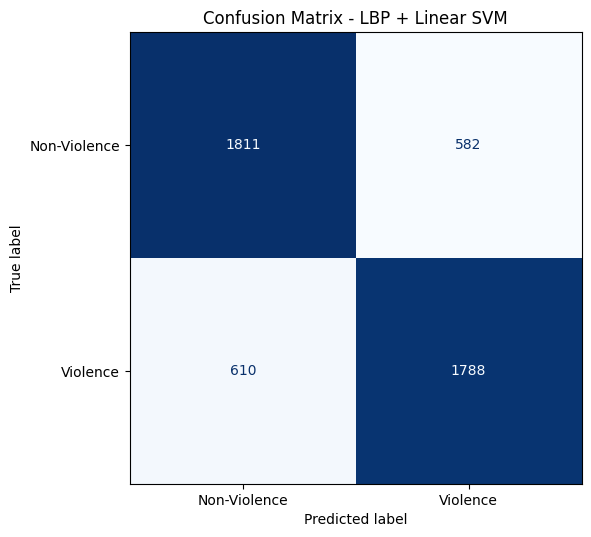


Confusion Matrix Saved Successfully
/content/drive/MyDrive/LBP_SVM_Violence_Detection/graphs/confusion_matrix.png


In [8]:
# ============================================================
# Cell 8 : Confusion Matrix Visualization
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

print("="*60)
print("Generating Confusion Matrix")
print("="*60)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Violence", "Violence"]
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix - LBP + Linear SVM")
plt.tight_layout()

CONFUSION_PATH = os.path.join(
    GRAPH_DIR,
    "confusion_matrix.png"
)

plt.savefig(CONFUSION_PATH, dpi=300)

plt.show()

print("\nConfusion Matrix Saved Successfully")

print(CONFUSION_PATH)

print("="*60)

Generating ROC Curve


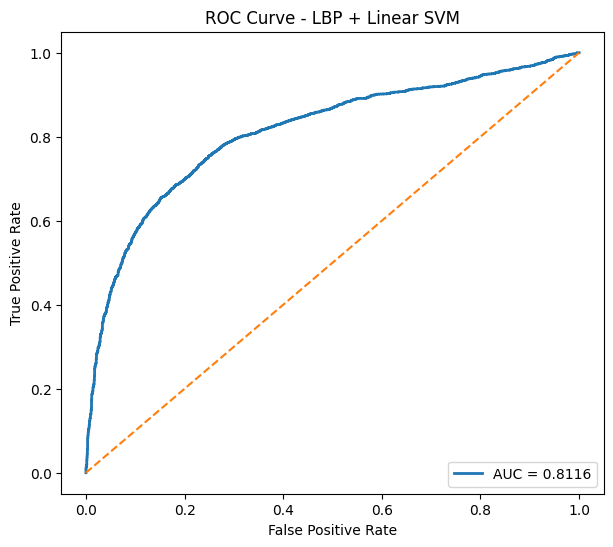

AUC Score : 0.8116

ROC Curve Saved Successfully
/content/drive/MyDrive/LBP_SVM_Violence_Detection/graphs/roc_curve.png


In [9]:
# ============================================================
# Cell 9 : ROC Curve
# ============================================================

from sklearn.metrics import roc_curve, auc

print("="*60)
print("Generating ROC Curve")
print("="*60)

fpr, tpr, thresholds = roc_curve(
    y_test_features,
    y_scores
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LBP + Linear SVM")

plt.legend(loc="lower right")

ROC_PATH = os.path.join(
    GRAPH_DIR,
    "roc_curve.png"
)

plt.savefig(ROC_PATH, dpi=300)

plt.show()

print(f"AUC Score : {roc_auc:.4f}")

print("\nROC Curve Saved Successfully")

print(ROC_PATH)

print("="*60)

In [10]:
# ============================================================
# Cell 10 : Save Metrics & Model Information
# ============================================================

import json
import os

print("="*60)
print("Saving Reports")
print("="*60)

metrics = {
    "Model": "LBP + Linear SVM",
    "Accuracy": round(float(accuracy), 4),
    "Precision": round(float(precision), 4),
    "Recall": round(float(recall), 4),
    "F1_Score": round(float(f1), 4),
    "ROC_AUC": round(float(roc_auc), 4),
    "Training_Time_Seconds": round(float(training_time), 2),
    "Prediction_Time_Seconds": round(float(prediction_time), 4),
    "Best_C": float(grid_search.best_params_["C"]),
    "Cross_Validation_Accuracy": round(float(grid_search.best_score_), 4)
}

model_info = {
    "Model_Name": "LBP + Linear SVM",
    "Feature_Extraction": "Uniform Local Binary Pattern (LBP)",
    "Classifier": "LinearSVC",
    "Radius": RADIUS,
    "Neighbors": N_POINTS,
    "LBP_Method": METHOD,
    "Feature_Dimension": int(X_train_features.shape[1]),
    "Training_Samples": int(len(X_train_features)),
    "Testing_Samples": int(len(X_test_features))
}

with open(os.path.join(REPORT_DIR, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=4)

with open(os.path.join(REPORT_DIR, "model_info.json"), "w") as f:
    json.dump(model_info, f, indent=4)

with open(os.path.join(REPORT_DIR, "classification_report.txt"), "w") as f:
    f.write(report)

print("✓ metrics.json saved")
print("✓ model_info.json saved")
print("✓ classification_report.txt saved")

print("\nReport Location:")
print(REPORT_DIR)

print("="*60)

Saving Reports
✓ metrics.json saved
✓ model_info.json saved
✓ classification_report.txt saved

Report Location:
/content/drive/MyDrive/LBP_SVM_Violence_Detection/reports


In [13]:
# ============================================================
# Cell 11 : Final Experiment Summary
# ============================================================

import os

print("="*70)
print("           REAL-TIME VIOLENCE DETECTION")
print("      Traditional Machine Learning Baseline")
print("             LBP + Linear SVM")
print("="*70)

print("\nDataset Information")
print("-"*70)
print(f"Total Images           : {len(X_train) + len(X_test)}")
print(f"Training Images        : {len(X_train)}")
print(f"Testing Images         : {len(X_test)}")

print("\nFeature Extraction")
print("-"*70)
print("Feature Type           : Uniform Local Binary Pattern (LBP)")
print(f"Radius                 : {RADIUS}")
print(f"Neighbors              : {N_POINTS}")
print(f"Feature Dimension      : {X_train_features.shape[1]}")

print("\nClassifier")
print("-"*70)
print("Classifier             : Linear Support Vector Machine")
print(f"Best C Value           : {grid_search.best_params_['C']}")
print(f"Cross Validation Acc.  : {grid_search.best_score_*100:.2f}%")

print("\nPerformance Metrics")
print("-"*70)
print(f"Accuracy               : {accuracy*100:.2f}%")
print(f"Precision              : {precision*100:.2f}%")
print(f"Recall                 : {recall*100:.2f}%")
print(f"F1 Score               : {f1*100:.2f}%")
print(f"ROC AUC Score          : {roc_auc:.4f}")

print("\nExecution Time")
print("-"*70)
print(f"Training Time          : {training_time:.2f} seconds")
print(f"Prediction Time        : {prediction_time:.4f} seconds")

print("\nGenerated Files")
print("-"*70)
print(f"Model                  : {MODEL_PATH}")
print(f"Reports                : {REPORT_DIR}")
print(f"Graphs                 : {GRAPH_DIR}")

print("\nNotebook Status")
print("-"*70)
print("✓ Feature Extraction Completed")
print("✓ Hyperparameter Tuning Completed")
print("✓ Model Training Completed")
print("✓ Model Evaluation Completed")
print("✓ Confusion Matrix Generated")
print("✓ ROC Curve Generated")
print("✓ Model Saved")
print("✓ Reports Saved")

print("="*70)
print("Project Completed Successfully")
print("="*70)

           REAL-TIME VIOLENCE DETECTION
      Traditional Machine Learning Baseline
             LBP + Linear SVM

Dataset Information
----------------------------------------------------------------------
Total Images           : 23952
Training Images        : 19161
Testing Images         : 4791

Feature Extraction
----------------------------------------------------------------------
Feature Type           : Uniform Local Binary Pattern (LBP)
Radius                 : 1
Neighbors              : 8
Feature Dimension      : 10

Classifier
----------------------------------------------------------------------
Classifier             : Linear Support Vector Machine
Best C Value           : 100
Cross Validation Acc.  : 74.20%

Performance Metrics
----------------------------------------------------------------------
Accuracy               : 75.12%
Precision              : 75.44%
Recall                 : 74.56%
F1 Score               : 75.00%
ROC AUC Score          : 0.8116

Execution Time
--

In [14]:
import shutil
from google.colab import files

zip_name = "LBP_SVM_Violence_Detection.zip"

shutil.make_archive(
    "LBP_SVM_Violence_Detection",
    'zip',
    PROJECT_DIR
)

files.download(zip_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>